In [76]:
import numpy as np
import pandas as pd

df = pd.read_csv('linear_regression_dataset.csv')


df['RACE'] = df['RACE'].fillna(df['RACE'].mode()[0])
features = ['AGE', 'FEMALE', 'LOS', 'RACE', 'APRDRG']
X = df[features].values
y = df['TOTCHG'].values
df.isnull().sum()

AGE       0
FEMALE    0
LOS       0
RACE      0
TOTCHG    0
APRDRG    0
dtype: int64

In [77]:
np.random.seed(42) 
m = X.shape[0]
indices = np.arange(m)
np.random.shuffle(indices)

train_size = int(0.8 * m)
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

X_train_norm = (X_train - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

In [78]:
def model(X, w, b):
   return np.dot(X, w) + b

def compute_cost(X, y, w, b):
    m = X.shape[0]
    f_wb = model(X, w, b)
    cost = np.sum((f_wb - y)**2) / (2 * m)
    return cost

def compute_gradient(X, y, w, b):
    m, n = X.shape
    f_wb = model(X, w, b)
    err = f_wb - y
    
    dj_dw = np.dot(X.T, err) / m
    dj_db = np.sum(err) / m
    return dj_dw, dj_db

def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    w = w_in
    b = b_in
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(X, y, w, b))
        # Print cost every 100 iterations
        if i % 100 == 0:
            print(f"Iteration {i:4d}: Cost {compute_cost(X, y, w, b):.2f}")
            
    return w, b , cost_history

In [79]:

w_init = np.zeros(X_train_norm.shape[1])
b_init = 0.
alpha = 0.1
iterations = 1000

w_final, b_final,cost_history = gradient_descent(X_train_norm, y_train, w_init, b_init, alpha, iterations)


y_test_pred = model(X_test_norm, w_final, b_final)


ss_res = np.sum((y_test - y_test_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2_test = 1 - (ss_res / ss_tot)

Iteration    0: Cost 9861256.26
Iteration  100: Cost 3988464.01
Iteration  200: Cost 3988463.97
Iteration  300: Cost 3988463.97
Iteration  400: Cost 3988463.97
Iteration  500: Cost 3988463.97
Iteration  600: Cost 3988463.97
Iteration  700: Cost 3988463.97
Iteration  800: Cost 3988463.97
Iteration  900: Cost 3988463.97


In [80]:
print("\n--- Final Results ---")
print(f"Final Weights: {w_final}")
print(f"Final Bias: {b_final:.2f}")
print(f"Test Set R-squared: {r2_test:.4f}")


--- Final Results ---
Final Weights: [  987.7336008   -190.19080785  2238.29183356  -102.27164093
 -1264.36724085]
Final Bias: 2700.48
Test Set R-squared: 0.8617


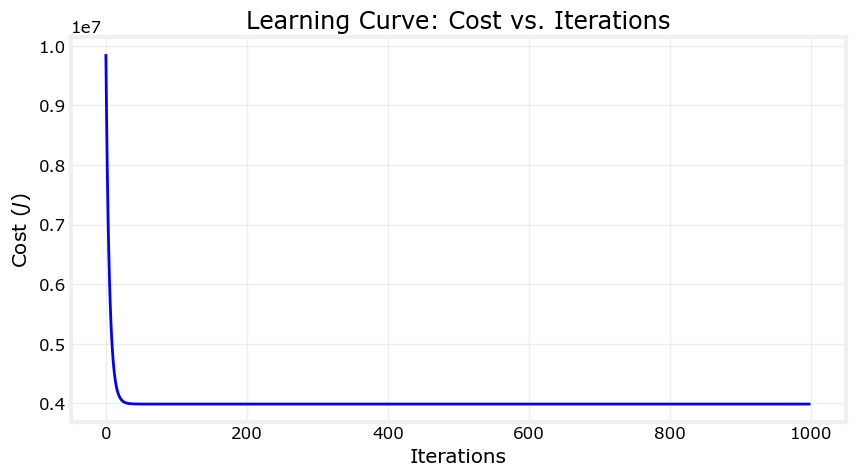

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(cost_history, color='blue', lw=2)
plt.title('Learning Curve: Cost vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost ($J$)')
plt.grid(True, alpha=0.3)
plt.show()

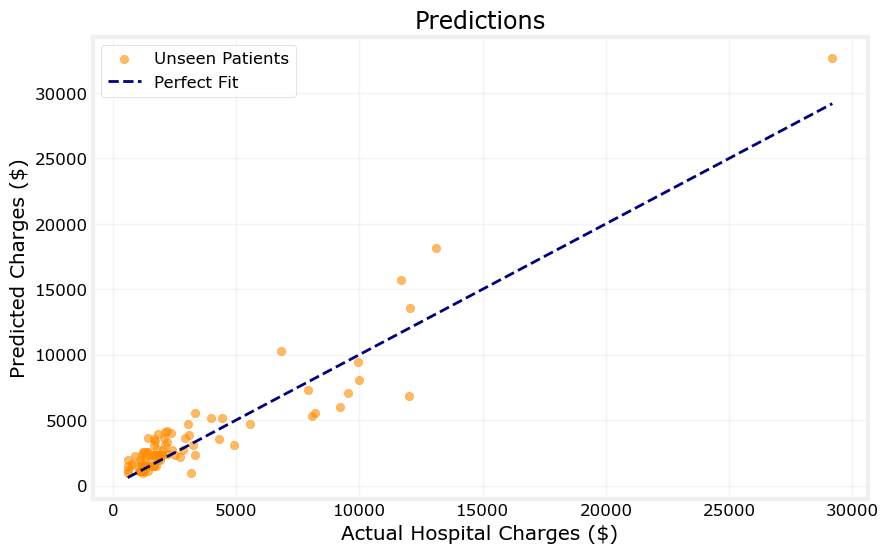

In [82]:
plt.figure(figsize=(10, 6))
# Plotting the test set results
plt.scatter(y_test, y_test_pred, alpha=0.6, color='darkorange', label='Unseen Patients')
# Plotting the 'Perfect Match' line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='navy', lw=2, label='Perfect Fit')

plt.title('Predictions')
plt.xlabel('Actual Hospital Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

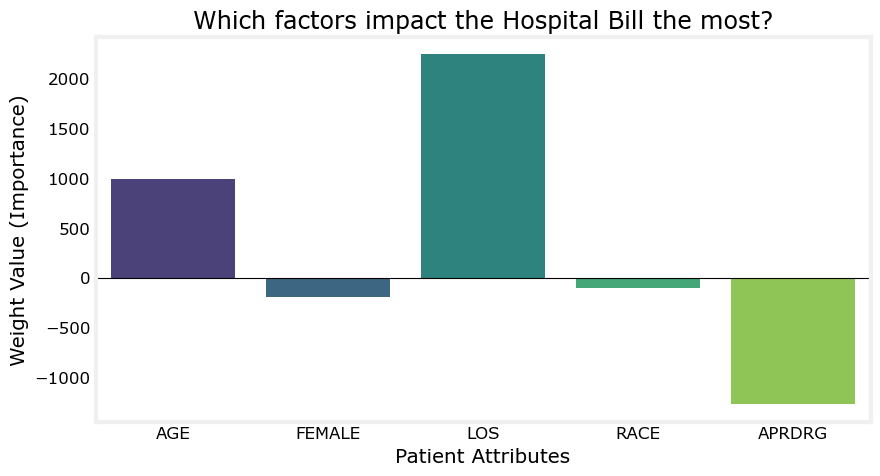

In [84]:
import seaborn as sns

plt.figure(figsize=(10, 5))
# We use the 'features' list you defined earlier: ['AGE', 'FEMALE', 'LOS', 'RACE', 'APRDRG']
sns.barplot(x=features, y=w_final,hue=features, palette='viridis',legend=False)

plt.axhline(0, color='black', linewidth=0.8) # Line at zero
plt.title('Which factors impact the Hospital Bill the most?')
plt.ylabel('Weight Value (Importance)')
plt.xlabel('Patient Attributes')
plt.show()